In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df= pd.read_excel("website_traffic_complete_dataset.xlsx")

In [10]:
df.head()

,Date,Traffic_Source,Sessions,Users,Bounce_Rate_Percent,Session_Duration_Min,Pages_Per_Session,Landing_Page,Page_Views,Exit_Rate_Percent,Conversions,Goal_Completions,Revenue,Device_Type,Country
0,2024-11-23,Social,278,182,36.50,2.62,6.21,Home,1726,16.64,23,40,609.92,Desktop,India
1,2024-09-15,Organic,1282,843,31.93,6.67,4.91,Pricing,6294,53.40,43,61,2702.82,Mobile,UK
2,2024-03-20,Organic,490,459,40.20,1.38,1.86,Services,911,44.49,50,69,3012.95,Mobile,USA
3,2024-10-09,Referral,650,584,57.11,8.69,5.13,Products,3334,62.04,56,57,7595.84,Desktop,Canada
4,2024-05-22,Email,978,822,41.89,4.02,2.62,Pricing,2562,44.38,38,58,895.53,Desktop,India


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  5000 non-null   object 
 1   Traffic_Source        5000 non-null   object 
 2   Sessions              5000 non-null   int64  
 3   Users                 5000 non-null   int64  
 4   Bounce_Rate_Percent   5000 non-null   float64
 5   Session_Duration_Min  5000 non-null   float64
 6   Pages_Per_Session     5000 non-null   float64
 7   Landing_Page          5000 non-null   object 
 8   Page_Views            5000 non-null   int64  
 9   Exit_Rate_Percent     5000 non-null   float64
 10  Conversions           5000 non-null   int64  
 11  Goal_Completions      5000 non-null   int64  
 12  Revenue               5000 non-null   float64
 13  Device_Type           5000 non-null   object 
 14  Country               5000 non-null   object 
dtypes: float64(5), int64(

In [12]:
df.describe()

,Sessions,Users,Bounce_Rate_Percent,Session_Duration_Min,Pages_Per_Session,Page_Views,Exit_Rate_Percent,Conversions,Goal_Completions,Revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,781.281200,623.525000,49.981896,5.177962,4.60015,3592.014200,42.123946,50.636800,60.653200,5259.979882
std,419.828145,342.869832,17.246391,2.739603,1.97240,2605.609727,15.928674,39.362118,39.908063,5393.664156
min,50.000000,35.000000,20.040000,0.500000,1.20000,85.000000,15.000000,0.000000,1.000000,0.000000
25%,419.000000,330.000000,35.075000,2.760000,2.89000,1491.750000,28.392500,19.000000,28.000000,1336.957500
50%,787.000000,625.000000,50.485000,5.180000,4.60000,2955.500000,41.840000,41.000000,51.000000,3366.905000
75%,1148.000000,905.000000,64.630000,7.512500,6.33000,5216.250000,55.885000,75.000000,85.000000,7409.355000
max,1500.000000,1420.000000,79.980000,9.990000,8.00000,11627.000000,69.990000,175.000000,189.000000,32358.400000


# Objective 1: Identify Top Traffic Sources

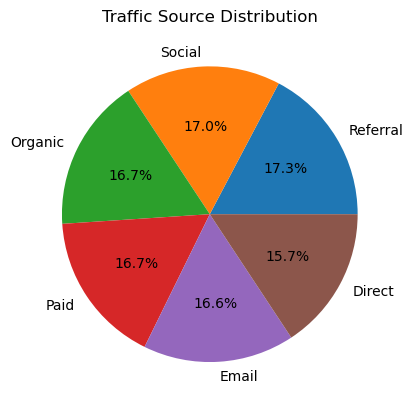

In [24]:
traffic_source = df.groupby('Traffic_Source')['Sessions'].sum().sort_values(ascending=False)
traffic_source
traffic_source.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")
plt.title("Traffic Source Distribution")
plt.show()

# Objective 2: User Engagement Analysis

# Average Session Duration and Average Pages Per Session

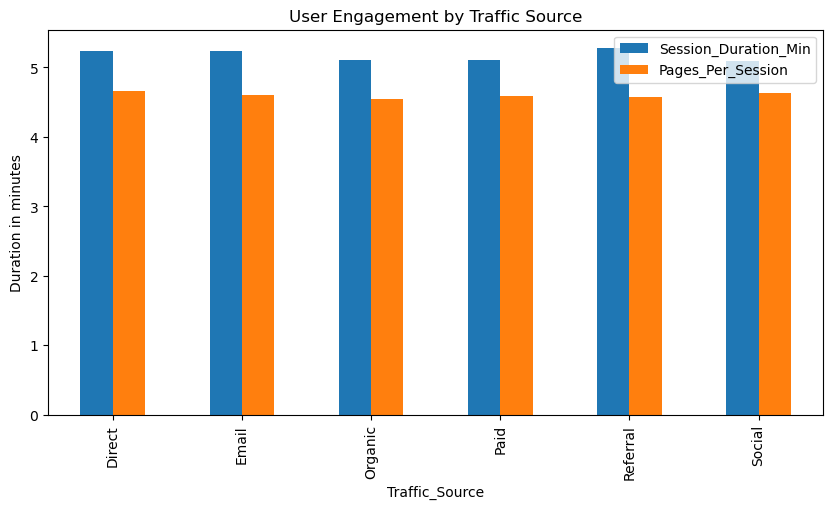

In [23]:
avg_duration = df['Session_Duration_Min'].mean()
avg_pages = df['Pages_Per_Session'].mean()
engagement = df.groupby('Traffic_Source')[['Session_Duration_Min',
                                          'Pages_Per_Session']].mean()

engagement
engagement.plot(kind='bar', figsize=(10,5))
plt.title("User Engagement by Traffic Source")
plt.ylabel("Duration in minutes")
plt.show()

# Objective 3: Conversion Rate and Goal Completions

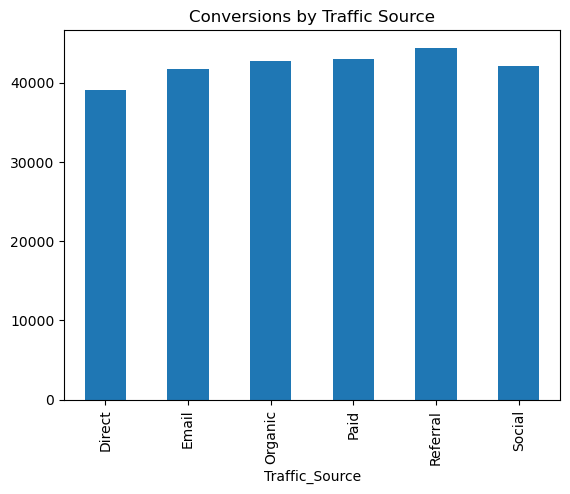

In [25]:
conversion_rate = (df['Conversions'].sum() /
                   df['Sessions'].sum()) * 100
total_goals = df['Goal_Completions'].sum()
source_conversion = df.groupby('Traffic_Source')['Conversions'].sum()

source_conversion.plot(kind='bar')
plt.title("Conversions by Traffic Source")
plt.show()

# Objective 4: High and Low Performing Pages

# Top Pages by Views

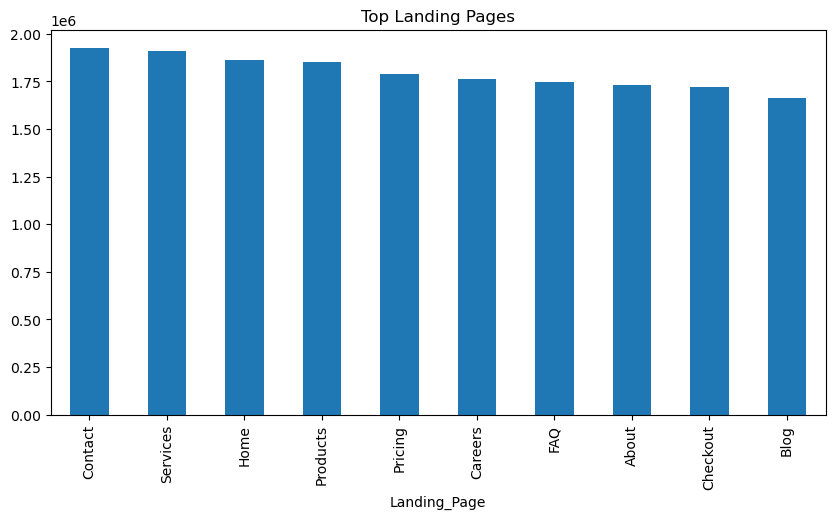

In [26]:
top_pages = df.groupby('Landing_Page')['Page_Views'].sum().sort_values(ascending=False)

top_pages
top_pages.plot(kind='bar', figsize=(10,5))
plt.title("Top Landing Pages")
plt.show()